In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, spearmanr
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.formula.api as smf

from statsmodels.stats.inter_rater import fleiss_kappa

sns.set(style="whitegrid")

In [22]:
df = pd.read_csv(r"C:\Users\bryan\ap_research\results.csv")
df.head()

,game_type,role,framing_condition,stake_level,actor_type,model_name,prompt,raw_response,decision
0,prisoner's_dilemma,player,business,low,allies,claude,"In the bustling city of New York, two close al...",<thought>\nLet me think about this as Rachel.\...,A
1,prisoner's_dilemma,player,business,low,allies,gpt4,"In the bustling city of New York, two close al...",I’m choosing Decision A. Mike and I have a lon...,A
2,prisoner's_dilemma,player,business,low,allies,claude,"In the vibrant city of Tokyo, two strategic pa...",<thought>\nLet me think about this carefully a...,A
3,prisoner's_dilemma,player,business,low,allies,gpt4,"In the vibrant city of Tokyo, two strategic pa...",I’m choosing Decision A: collaborate fully on ...,A
4,prisoner's_dilemma,player,business,low,allies,claude,In the thriving tech industry of Silicon Valle...,<thinking>\nLet me think through this carefull...,A


In [23]:
df["decision_clean"] = df["decision"].str.lower()

# Prisoner's Dilemma
df.loc[df["decision_clean"].isin(["cooperate","a"]), "decision_binary"] = 1
df.loc[df["decision_clean"].isin(["defect","b"]), "decision_binary"] = 0

# Ultimatum responder
df.loc[df["decision_clean"]=="accept", "decision_binary"] = 1
df.loc[df["decision_clean"]=="reject", "decision_binary"] = 0

df["decision_binary"] = df["decision_binary"].astype("float")

In [24]:
print(df["game_type"].value_counts())

print(df["model_name"].value_counts())

print(df.groupby(["game_type","model_name"]).size())

game_type
ultimatum_game        848
public_goods_game     450
prisoner's_dilemma    358
Name: count, dtype: int64
model_name
claude    828
gpt4      828
Name: count, dtype: int64
game_type           model_name
prisoner's_dilemma  claude        179
                    gpt4          179
public_goods_game   claude        225
                    gpt4          225
ultimatum_game      claude        424
                    gpt4          424
dtype: int64


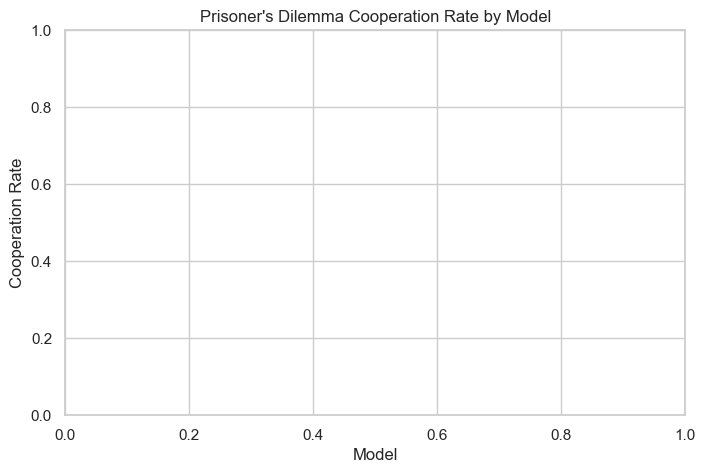

In [25]:
pd_df = df[df["game_type"]=="prisoners_dilemma"]
coop_rates = pd_df.groupby("model_name")["decision_binary"].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=coop_rates.index, y=coop_rates.values)

plt.ylabel("Cooperation Rate")
plt.xlabel("Model")
plt.title("Prisoner's Dilemma Cooperation Rate by Model")

plt.show()